In [8]:
import json
import re
from pathlib import Path
from matplotlib import pyplot as plt
from jaccard_plots import compute_chance_jaccard

import matplotlib.ticker as ticker

%matplotlib inline

In [9]:
_LAYER_RE = re.compile(r"^layers\.(\d+)$")

In [10]:
def plot_jaccard_per_good_percent(
    json_path: str | Path,
    save_dir: str | Path | None = None,
    show: bool = True,
    show_chance_line: bool = False,
):
    """
    Reads a jaccard_summary.json (list of entries) and, for each entry (i.e., each good_percent),
    creates TWO subplots stacked vertically:
      - Top plot: Jaccard Similarity per layer
      - Bottom plot: total_isolated_run1 and total_isolated_run2 per layer
                     labeled as "Math-specific English" and "Math-specific German"

    Args:
        json_path: path to jaccard_summary.json
        save_dir: if provided, saves one PNG per good_percent into this folder
        show: if True, calls plt.show() at the end
    """
    json_path = Path(json_path)
    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    def layer_index(name: str) -> int | None:
        m = _LAYERSAFE(name)
        if m is None:
            return None
        return int(m.group(1))

    def _LAYERSAFE(name: str):
        return _LAYER_RE.match(name)

    # Set publication-quality font sizes
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 9,
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
    })

    for entry in data:
        gp = entry.get("good_percent", None)
        seed = entry.get("seed", None)
        per_group = entry.get("per_group", {})

        # keep only "layers.N"
        layer_items = []
        for gname, stats in per_group.items():
            m = _LAYER_RE.match(gname)
            if not m:
                continue
            idx = int(m.group(1))
            layer_items.append((idx, gname, stats))

        if not layer_items:
            print(f"[WARN] No layer entries found for good_percent={gp}. Skipping.")
            continue

        # sort by Layer Index
        layer_items.sort(key=lambda t: t[0])

        x = [idx for idx, _, _ in layer_items]
        xlabels = [f"{idx}" for idx in x]

        jacc = [float(stats["jaccard"]) for _, _, stats in layer_items]
        iso_en = [int(stats["total_isolated_run1"]) for _, _, stats in layer_items]
        iso_de = [int(stats["total_isolated_run2"]) for _, _, stats in layer_items]

        # Create two subplots stacked vertically
        # ACL column width is ~3.33 inches, so use that width with appropriate height
        fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(4, 4), sharex=True)

        chance_jac = [compute_chance_jaccard(gp) for item in layer_items]

        # Top plot: Jaccard Similarity
        l1, = ax_top.plot(x, jacc, marker="o", label="Math-code", color="C0", linewidth=1.5, markersize=4)
        
        handles_top = [l1]
        labels_top = ["Math-code"]
        
        if show_chance_line:
            l2, = ax_top.plot(x, chance_jac, label="Chance", color="0.6", 
                       linestyle="--", linewidth=1.2, markersize=0)
            handles_top.append(l2)
            labels_top.append("Chance")
            

        ax_top.set_ylabel("Jaccard Similarity", fontsize=11)
        # set the max y limit to max jaccard + 0.05 for better visualization
        mmax = max(jacc)
        ax_top.set_ylim(chance_jac[0]-0.02, mmax + 0.05)
        # ax_top.legend(fontsize=8, framealpha=0.9)
        ax_top.grid(True, alpha=0.25, linewidth=0.5)
        
        title = f"Top-$k$={gp}"
        ax_top.set_title(title, pad=8)
        
        
        ax_top.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, min_n_ticks=4))


        # Bottom plot: isolated parameters
        b1, = ax_bottom.plot(x, iso_en, marker="^", color="green", label="Math",
                      linewidth=1.5, markersize=4, alpha=0.8)
        b2, = ax_bottom.plot(x, iso_de, marker="v", color="violet", label="Code",
                      linewidth=1.5, markersize=4)
        
        handles_bottom = [b1, b2]
        labels_bottom = ["Math", "Code"]

        ax_bottom.set_xlabel("Layer Index", fontsize=11)
        ax_bottom.set_ylabel("# Isolated Params", fontsize=11)
        ax_bottom.set_xticks(x[::2])  # Show every other layer to avoid crowding
        ax_bottom.set_xticklabels([xlabels[i] for i in range(0, len(xlabels), 2)], fontsize=9)
        # ax_bottom.legend(fontsize=8, framealpha=0.9)
        ax_bottom.grid(True, alpha=0.25, linewidth=0.5)

        min_val = min(min(iso_en), min(iso_de))
        max_val = max(max(iso_en), max(iso_de))
        ax_bottom.set_ylim(min_val * 0.75, max_val * 1.1)

        # Auto scale y-axis with scientific notation (e.g., x10^3 or x10^6)
        ax_bottom.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)
        ax_bottom.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)
        ax_bottom.yaxis.get_offset_text().set_size(9)

        
        formatter = ticker.ScalarFormatter(useMathText=True)

        # 2. Force scientific notation (the x10^3 part)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))

        # 3. Format the actual numbers to 2 decimal places 
        # This tells the formatter how to display the "scaled" numbers
        # formatter.format_data = lambda x: "%.2f" % x 
        # For newer Matplotlib versions, this is often the most reliable way:
        formatter.set_useOffset(True) 

        # 4. Apply it to the axis
        ax_bottom.yaxis.set_major_formatter(formatter)

        # Set offset text size as before
        ax_bottom.yaxis.get_offset_text().set_size(9)

        # set 3 y-ticks
        ax_bottom.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, min_n_ticks=3))
        

        fig.legend(
            handles_top,
            labels_top,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.01),
            ncol=len(handles_top),
            frameon=False,
            handlelength=2.0,
            columnspacing=1.5
        )

        fig.legend(
            handles_bottom,
            labels_bottom,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.01),
            ncol=2,
            frameon=False,
            handlelength=2.0,
            columnspacing=1.5
        )

        fig.align_ylabels([ax_top, ax_bottom])

        # Use tight layout with padding
        plt.tight_layout(rect=[0, 0.06, 1, 0.94])

        if save_dir is not None:
            # safe filename
            gp_str = str(gp)
            if show_chance_line:
                out_path = save_dir / f"jaccard_layers_with_chance_{gp_str}_seed_{seed}.pdf"
            else:
                out_path = save_dir / f"jaccard_layers_{gp_str}_seed_{seed}.pdf"
            fig.savefig(out_path, dpi=300, bbox_inches='tight')
            print("Saved:", out_path)

        if show:
            plt.show()
            break
        else:
            plt.close(fig)


In [11]:
# seed = 42
# plot_jaccard_per_good_percent(
#     f"/raid/s3/opengptx/behzad_shomali/LabTest/MathNeuro/jaccard_results/code_race/jaccard_summary_{seed}.json",
#     save_dir="../plotting_stuff/jaccard_results/code_race_Llama1B/",
#     show=False,
#     show_chance_line=True
# )

In [ ]:
def plot_jaccard_per_good_percent_multiple_datasets(
    json_path1: str | Path,
    json_path2: str | Path,
    json_path3: str | Path,
    pair_labels: tuple[str, str, str],
    normal_labels: tuple[str, str, str],
    save_dir: str | Path | None = None,
    show: bool = True,
    show_chance_line: bool = False,
):
    """
    Reads three jaccard_summary.json files and plots three Jaccard comparisons:
      - File 1: d1 vs d2 (e.g., English vs German)
      - File 2: d2 vs d3 (e.g., German vs Hindi)
      - File 3: d1 vs d3 (e.g., English vs Hindi)

    Args:
        json_path1: path to first jaccard_summary.json (d1 vs d2)
        json_path2: path to second jaccard_summary.json (d2 vs d3)
        json_path3: path to third jaccard_summary.json (d1 vs d3)
        pair_labels: tuple of 3 labels for the pairs (e.g., ("English-German", "German-Hindi", "English-Hindi"))
        normal_labels: tuple of 3 labels for the isolated params (e.g., ("English", "German", "Hindi"))
        save_dir: if provided, saves one PNG per good_percent into this folder
        show: if True, calls plt.show() at the end
    """
    json_path1 = Path(json_path1)
    with json_path1.open("r", encoding="utf-8") as f:
        data1 = json.load(f)

    json_path2 = Path(json_path2)
    with json_path2.open("r", encoding="utf-8") as f:
        data2 = json.load(f)

    json_path3 = Path(json_path3)
    with json_path3.open("r", encoding="utf-8") as f:
        data3 = json.load(f)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    def _LAYERSAFE(name: str):
        return _LAYER_RE.match(name)

    # Set publication-quality font sizes
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 9,
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
    })

    # Process all three files - assuming they have the same structure
    for entry1, entry2, entry3 in zip(data1, data2, data3):
        gp = entry1.get("good_percent", None)
        seed = entry1.get("seed", None)
        per_group1 = entry1.get("per_group", {})
        per_group2 = entry2.get("per_group", {})
        per_group3 = entry3.get("per_group", {})

        # Extract layer data from file 1
        layer_items1 = []
        for gname, stats in per_group1.items():
            m = _LAYER_RE.match(gname)
            if not m:
                continue
            idx = int(m.group(1))
            layer_items1.append((idx, gname, stats))

        # Extract layer data from file 2
        layer_items2 = []
        for gname, stats in per_group2.items():
            m = _LAYER_RE.match(gname)
            if not m:
                continue
            idx = int(m.group(1))
            layer_items2.append((idx, gname, stats))

        # Extract layer data from file 3
        layer_items3 = []
        for gname, stats in per_group3.items():
            m = _LAYER_RE.match(gname)
            if not m:
                continue
            idx = int(m.group(1))
            layer_items3.append((idx, gname, stats))

        if not layer_items1 or not layer_items2 or not layer_items3:
            print(f"[WARN] No layer entries found for good_percent={gp}. Skipping.")
            continue

        # Sort by Layer Index
        layer_items1.sort(key=lambda t: t[0])
        layer_items2.sort(key=lambda t: t[0])
        layer_items3.sort(key=lambda t: t[0])

        x = [idx for idx, _, _ in layer_items1]
        xlabels = [f"{idx}" for idx in x]

        # Extract Jaccard values from all three files
        jacc_d1_d2 = [float(stats["jaccard"]) for _, _, stats in layer_items1]  # d1 vs d2 (e.g., English vs German)
        jacc_d2_d3 = [float(stats["jaccard"]) for _, _, stats in layer_items2]  # d2 vs d3 (e.g., German vs Hindi)
        jacc_d1_d3 = [float(stats["jaccard"]) for _, _, stats in layer_items3]  # d1 vs d3 (e.g., English vs Hindi)
        
        # Extract isolated parameters
        # From file 1: d1 (run1) and d2 (run2)
        iso_d1 = [int(stats["total_isolated_run1"]) for _, _, stats in layer_items1]  # e.g., English
        iso_d2 = [int(stats["total_isolated_run2"]) for _, _, stats in layer_items1]  # e.g., German
        # From file 2: d3 (run2) - run1 should be d2 which we already have
        iso_d3 = [int(stats["total_isolated_run2"]) for _, _, stats in layer_items2]  # e.g., Hindi
        
        # Create two subplots stacked vertically
        fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(4, 4), sharex=True)

        chance_jac = [compute_chance_jaccard(gp) for _ in layer_items1]

        markersize = 4 if len(x) <= 20 else 2

        # Top plot: Three Jaccard Similarity lines
        l1, = ax_top.plot(x, jacc_d1_d2, marker="o", label=pair_labels[0], color="C0", 
                   linewidth=1.5, markersize=markersize)
        l2, = ax_top.plot(x, jacc_d2_d3, marker="s", label=pair_labels[1], color="C1", 
                   linewidth=1.5, markersize=markersize)
        l3, = ax_top.plot(x, jacc_d1_d3, marker="^", label=pair_labels[2], color="C3", 
                   linewidth=1.5, markersize=markersize)
        
        handles_top = [l1, l2, l3]
        labels_top = list(pair_labels)
        
        if show_chance_line:
            l4, = ax_top.plot(x, chance_jac, label="Chance", color="0.6", 
                       linestyle="--", linewidth=1.2, markersize=0)
            handles_top.append(l4)
            labels_top.append("Chance")

        ax_top.set_ylabel("Jaccard Similarity", fontsize=11)
        # ax_top.set_ylim(0.0, 0.5)
        # ax_top.legend(fontsize=8, framealpha=0.9, loc="best")
        ax_top.grid(True, alpha=0.25, linewidth=0.5)
        
        title = f"Top-$k$={gp}"
        ax_top.set_title(title, pad=8)
        # ax_top.set_title(title, pad=18)

        min_jac = min(min(jacc_d1_d2), min(jacc_d2_d3), min(jacc_d1_d3))
        max_jac = max(max(jacc_d1_d2), max(jacc_d2_d3), max(jacc_d1_d3))
        ax_top.set_ylim(chance_jac[0] - 0.02, max_jac + 0.05)
        ax_top.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, min_n_ticks=4))


        # Bottom plot: isolated parameters for d1, d2, d3
        b1, = ax_bottom.plot(x, iso_d1, marker="o", color="green", label=normal_labels[0],
                      linewidth=1.5, markersize=markersize, alpha=0.8)
        b2, = ax_bottom.plot(x, iso_d2, marker="s", color="violet", label=normal_labels[1],
                      linewidth=1.5, markersize=markersize)
        b3, = ax_bottom.plot(x, iso_d3, marker="^", color="orange", label=normal_labels[2],
                      linewidth=1.5, markersize=markersize)
        
        handles_bottom = [b1, b2, b3]
        labels_bottom = list(normal_labels)

        ax_bottom.set_xlabel("Layer Index", fontsize=11)
        ax_bottom.set_ylabel("# Isolated Params", fontsize=11)

        xticks_step = 2 if len(x) <= 20 else 3

        ax_bottom.set_xticks(x[::xticks_step])  # Show every other layer to avoid crowding
        ax_bottom.set_xticklabels([xlabels[i] for i in range(0, len(xlabels), xticks_step)], fontsize=9)
        # ax_bottom.legend(fontsize=8, framealpha=0.9, loc="best")
        ax_bottom.grid(True, alpha=0.25, linewidth=0.5)

        min_val = min(min(iso_d1), min(iso_d2), min(iso_d3))
        max_val = max(max(iso_d1), max(iso_d2), max(iso_d3))
        ax_bottom.set_ylim(min_val * 0.75, max_val * 1.1)
        

        # Auto scale y-axis with scientific notation
        formatter = ticker.ScalarFormatter(useMathText=True)

        # 2. Force scientific notation (the x10^3 part)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))

        # 3. Format the actual numbers to 2 decimal places 
        # This tells the formatter how to display the "scaled" numbers
        # formatter.format_data = lambda x: "%.2f" % x 
        # For newer Matplotlib versions, this is often the most reliable way:
        formatter.set_useOffset(True) 

        # 4. Apply it to the axis
        ax_bottom.yaxis.set_major_formatter(formatter)
        ax_bottom.yaxis.get_offset_text().set_size(9)

        # set 3 y-ticks
        ax_bottom.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, min_n_ticks=3))

        fig.legend(
            handles_top,
            labels_top,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.01),
            ncol=len(handles_top),
            frameon=False,
            handlelength=2.0,
            columnspacing=1.5
        )

        fig.legend(
            handles_bottom,
            labels_bottom,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.01),
            ncol=3,
            frameon=False,
            handlelength=2.0,
            columnspacing=1.5
        )

        fig.align_ylabels([ax_top, ax_bottom])

        # Use tight layout with padding
        plt.tight_layout(rect=[0, 0.06, 1, 0.94])

        if save_dir is not None:
            gp_str = str(gp)
            if show_chance_line:
                out_path = save_dir / f"jaccard_multi_with_chance_{gp_str}_seed_{seed}.pdf"
            else:
                out_path = save_dir / f"jaccard_multi_{gp_str}_seed_{seed}.pdf"
            fig.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0.02)
            print("Saved:", out_path)

        if show:
            plt.show()
            break
        else:
            plt.close(fig)


In [13]:
seed = 42
# en_de_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_de_Qwen3-4B/repeat0/jaccard_summary.json"
# de_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_de_vs_hi_Qwen3-4B/repeat0/jaccard_summary.json"
# en_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_hi_Qwen3-4B/repeat0/jaccard_summary.json"

en_de_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_de_Llama-8B/repeat0/jaccard_summary.json"

plot_jaccard_per_good_percent_multiple_datasets(
    en_de_path,
    de_hi_path,
    en_hi_path,
    pair_labels=("En-De", "De-Hi", "En-Hi"),
    normal_labels=("En", "De", "Hi"),
    show=False,
    save_dir="../plotting_stuff/jaccard_results/en_de_hi_Qwen3-4B/",
    show_chance_line=True
)

NameError: name 'de_hi_path' is not defined

In [14]:
def plot_jaccard_per_good_percent_globally(
    paths: list[str | Path],
    labels: tuple[str, str, str],
    labels_pair: tuple[str, str, str],
    show_chance_line: bool = False,
    save_dir: str | Path | None = None,
    show: bool = True,
    fontsize=15,
    legend_fontsize=12,
    linewidth=1.5
):
    """
    Reads three jaccard_summary.json files and plots two side-by-side plots:
      - Left: # math-specific params vs Top k% (for the single datasets)
      - Right: Jaccard Similarity vs Top k% (for the pairs)

    Args:
        paths: list of paths to jaccard_summary.json files
               Assumption: [d1_vs_d2, d2_vs_d3, d1_vs_d3]
        labels: labels for single datasets [d1, d2, d3]
        labels_pair: labels for pairs [pair1, pair2, pair3]
    """
    all_data = []
    for p in paths:
        p = Path(p)
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)
            # Sort by good_percent to ensure correct plotting order
            data.sort(key=lambda x: x.get("good_percent", 0))
            all_data.append(data)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    # Prepare data for plotting
    # Assuming all files share the same good_percent points
    ref_data = all_data[0]
    xs = [entry["good_percent"] * 100 for entry in ref_data]  # Convert to percentage

    # Extract Jaccards (Right Plot)
    # paths[0] -> pair1, paths[1] -> pair2, paths[2] -> pair3
    jaccards = []
    for data in all_data:
        j_vals = [entry["global"]["jaccard"] for entry in data]
        jaccards.append(j_vals)
    
    # Extract Isolated Params (Left Plot)
    # File 1 (d1 vs d2): run1 -> d1, run2 -> d2
    iso_d1 = [entry["global"]["total_isolated_run1"] for entry in all_data[0]]
    iso_d2 = [entry["global"]["total_isolated_run2"] for entry in all_data[0]]
    # File 2 (d2 vs d3): run2 -> d3
    iso_d3 = [entry["global"]["total_isolated_run2"] for entry in all_data[1]]

    # Plotting
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 18,
        'axes.titlesize': 13,
        'xtick.labelsize': 13,
        'ytick.labelsize': 14,
        'legend.fontsize': legend_fontsize,
        'lines.linewidth': linewidth,
        'lines.markersize': 6,
    })

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(9, 3.5))

    # Left Plot: # Parameters
    # Using markers/colors similar to previous plots or the attachment
    # Attachment: German (Blue), English (Yellow), Hindi (Grey/dashed)
    # Previous code: Green, Violet, Orange for 3 datasets.
    # Let's match previous code style for consistency: d1=Green, d2=Violet, d3=Orange.
    
    # If we want to match the Attachment exactly:
    # ax_left.plot(xs, iso_d2, marker="o", label=labels[1], color="#1f77b4") # German-ish Blue
    # ax_left.plot(xs, iso_d1, marker="s", label=labels[0], color="#ff7f0e", linestyle="--") # English-ish Orange
    # ax_left.plot(xs, iso_d3, marker="v", label=labels[2], color="grey", linestyle=":") # Hindi-ish Grey

    markevery = max(1, len(xs) // 6)
    markersize = 5 if len(xs) <= 20 else 3

    # Using previous code colors:
    l1, = ax_left.plot(xs, iso_d1, marker="o", label=labels[0], color="green", alpha=0.8, markevery=markevery, markersize=markersize)
    l2, = ax_left.plot(xs, iso_d2, marker="s", label=labels[1], color="violet", markevery=markevery, markersize=markersize)
    l3, = ax_left.plot(xs, iso_d3, marker="^", label=labels[2], color="orange", markevery=markevery, markersize=markersize)


    ax_left.set_xlabel("Top $k$%", fontsize=fontsize)
    ax_left.set_ylabel("# Math-specific Params", fontsize=fontsize)
    ax_left.grid(True, alpha=0.25, linewidth=0.5)
    
    # Scientific notation for Y axis
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    formatter.set_useOffset(True)
    ax_left.yaxis.set_major_formatter(formatter)
    
    # Check if x ticks need formatting (e.g. 1%, 5%, 10%)
    # Current xs are floats like 1.0, 5.0.
    # ax_left.set_xticks(xs[::len(xs)//4 if len(xs) > 4 else 1])
    # Add '%' to xticks? No, label says Top k%.
    ax_left.xaxis.set_major_formatter(ticker.FormatStrFormatter('%g')) 

    ax_left.set_xticks([0.1, 5, 10, 15])
    ax_right.set_xticks([0.1, 5, 10, 15])


    # Right Plot: Jaccard Similarity
    # Colors: C0, C1, C3 (Blue, Orange, Red)
    r1, = ax_right.plot(xs, jaccards[0], marker="o", label=labels_pair[0], color="C0", markevery=markevery, markersize=markersize) # Blue
    r2, = ax_right.plot(xs, jaccards[1], marker="o", label=labels_pair[1], color="C1", markevery=markevery, markersize=markersize) # Orange ?
    r3, = ax_right.plot(xs, jaccards[2], marker="o", label=labels_pair[2], color="C3", markevery=markevery, markersize=markersize) # Red

    handles_right = [r1, r2, r3]
    labels_right = list(labels_pair)

    print(xs)
    if show_chance_line:
        chance_jac = [compute_chance_jaccard(gp/100) for gp in xs]
        r4, = ax_right.plot(xs, chance_jac, label="Chance", color="0.6", linestyle="--", linewidth=1.2, markersize=0)
        handles_right.append(r4)
        labels_right.append("Chance")

    ax_right.set_xlabel("Top $k$%", fontsize=fontsize)
    ax_right.set_ylabel("Jaccard Similarity", fontsize=fontsize)
    ax_right.grid(True, alpha=0.25, linewidth=0.5)
    ax_right.set_ylim(-0.001, max(max(j) for j in jaccards) + 0.05)
    ax_right.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4, min_n_ticks=4))
    
    ax_right.xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    # ax_right.set_xticks(xs[::len(xs)//5 if len(xs) > 5 else 1])

    # Add figure-level legends
    handles_left = [l1, l2, l3]
    labels_left = list(labels)

    fig.legend(
        handles_left,
        labels_left,
        loc="upper center",
        bbox_to_anchor=(0.25, 1.02),
        ncol=3,
        frameon=False,
        handlelength=2.0,
        columnspacing=1.5
    )

    fig.legend(
        handles_right,
        labels_right,
        loc="upper center",
        bbox_to_anchor=(0.75, 1.02),
        ncol=2,
        frameon=False,
        handlelength=2.0,
        columnspacing=1.5
    )

    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    if save_dir is not None:
        out_path = save_dir / f"jaccard_global_comparison.pdf"
        fig.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0.02)
        print("Saved:", out_path)


[0.01, 0.1, 1.0, 2.5, 5.0, 10.0, 15.0]
Saved: ../plotting_stuff/jaccard_results/en_de_hi_Qwen3-4B_global/jaccard_global_comparison.pdf


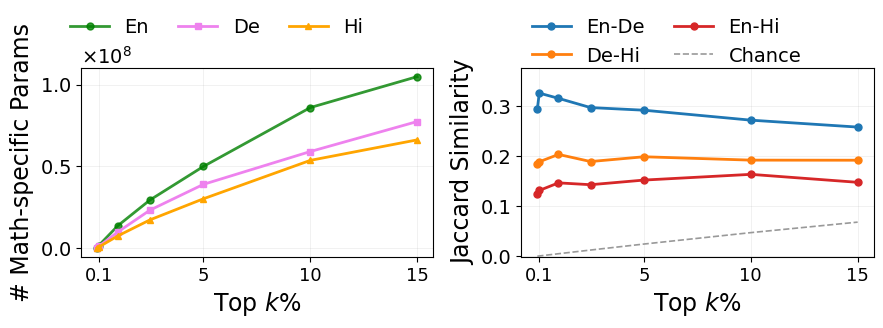

In [ ]:
# en_de_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_de_Llama-8B/repeat0/jaccard_summary.json"
# de_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_de_vs_hi_Llama-8B/repeat0/jaccard_summary.json"
# en_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_hi_Llama-8B/repeat0/jaccard_summary.json"

en_de_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_de_Qwen3-4B/repeat0/jaccard_summary.json"
de_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_de_vs_hi_Qwen3-4B/repeat0/jaccard_summary.json"
en_hi_path = "/raid/s3/opengptx/behzad_shomali/LabTest/results_jaccard/gsm8k_race_en_vs_hi_Qwen3-4B/repeat0/jaccard_summary.json"


plot_jaccard_per_good_percent_globally(
    paths=[en_de_path, de_hi_path, en_hi_path],
    labels=("En", "De", "Hi"),
    labels_pair=("En-De", "De-Hi", "En-Hi"),
    show_chance_line=True,
    save_dir="../plotting_stuff/jaccard_results/en_de_hi_Qwen3-4B/",
    show=True,
    fontsize=17,
    legend_fontsize=14,
    linewidth=2
)